## Sensibility test to the time step ##
### Using the average separation distance (compared to 1 min time step) ###

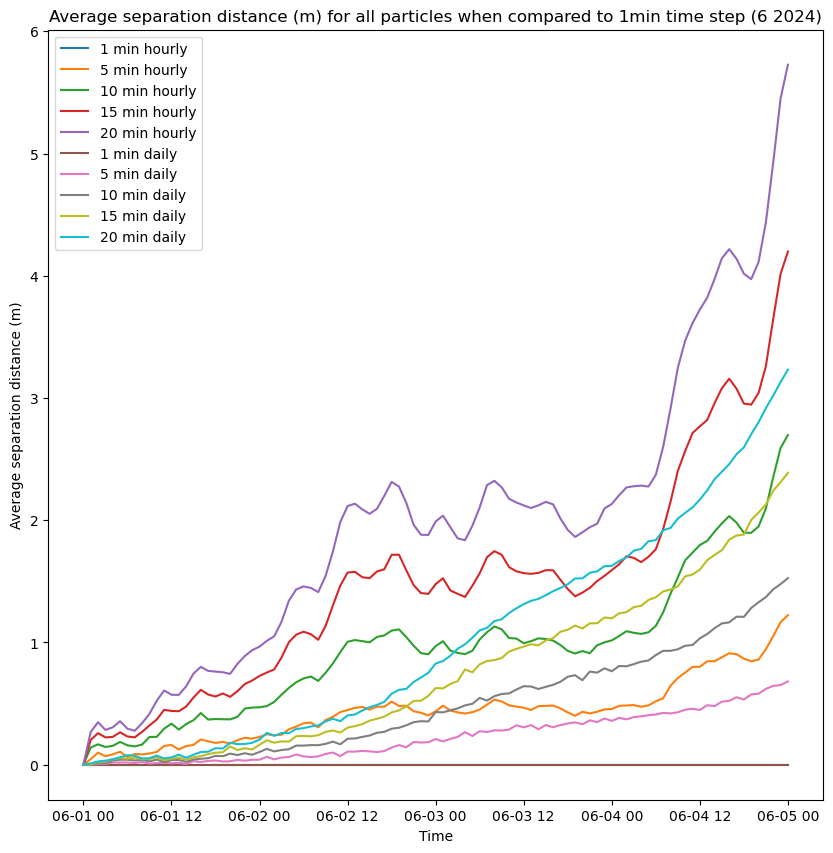

In [6]:
from datetime import datetime, timedelta
import datetime as dt
import numpy as np
import pandas as pd
import xarray as xr
import os
import matplotlib.pyplot as plt

R = 6371000
month = 6
fig, ax = plt.subplots(figsize=(10, 10))
for product in ['hourly', 'daily']:

    # compare particle difference to a baseline of 1min (assuming it is the most accurate)
    ds = xr.open_dataset('/scratch/project_2018610/opendrift_outputs/sensibility_test_time_step/sensibility_test_time_step_{}_1_month_{}.nc'.format(product, month))
    time, lon, lat = [ds[key] for key in ['time', 'lon', 'lat']]
    
    for tstep in [1, 5, 10, 15, 20]:
        
        ds = xr.open_dataset('/scratch/project_2018610/opendrift_outputs/sensibility_test_time_step/sensibility_test_time_step_{}_{}_month_{}.nc'.format(product, tstep, month))
        #Use of Haversine formula to calculate the distances
        #Caution ! Conversion in radian
        dlon = np.deg2rad(ds.lon - lon)
        dlat = np.deg2rad(ds.lat - lat)
        a = np.sin(dlat/2)**2 + np.cos(lat) * np.cos(ds.lat) * np.sin(dlon/2)**2
        d = 2 * np.arcsin(np.sqrt(a)) * R
        
        ax.plot(time, d.mean(axis=0), label=f'{tstep} min {product}')

ax.legend()
ax.set_title(f'Average separation distance (m) for all particles when compared to 1min time step ({month} 2024)')
ax.set_xlabel("Time")
ax.set_ylabel("Average separation distance (m)")
plt.show()
fig.savefig('sensibility_test_time_step_{}'.format(month))

### Using the average pair distance ###

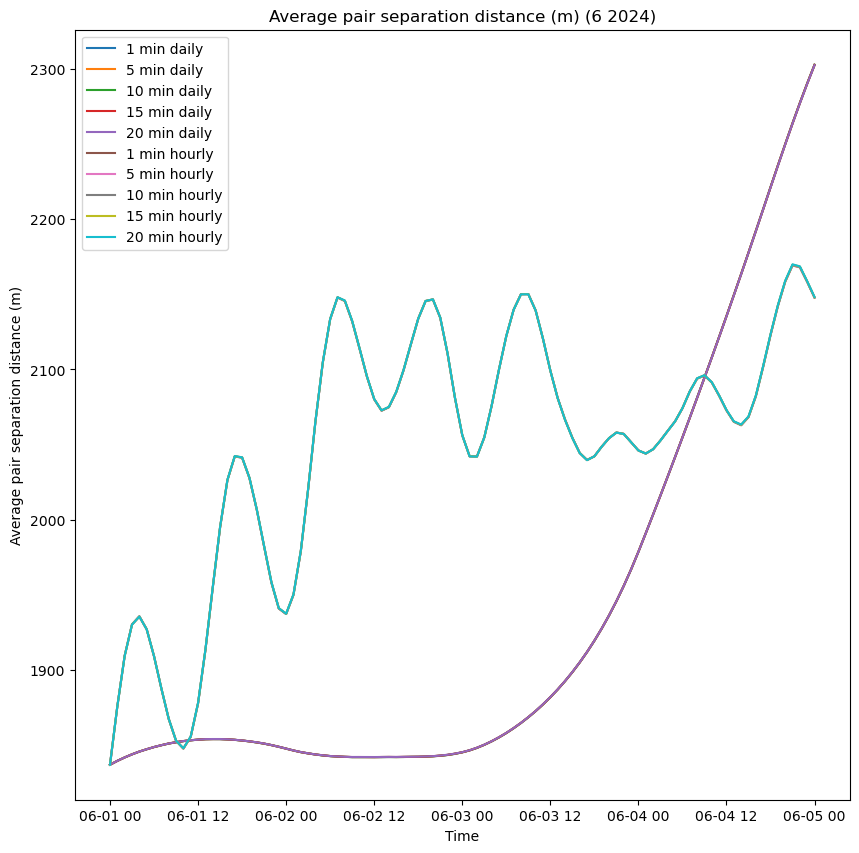

In [2]:
from datetime import datetime, timedelta
import datetime as dt
import numpy as np
import pandas as pd
import xarray as xr
import os
import matplotlib.pyplot as plt

def haversine(lon1, lon2, lat1, lat2, R = 6371000):
    dlon = lon2 -lon1
    dlat = lat2 -lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * np.arcsin(np.sqrt(a)) * R
month = 6

fig, ax = plt.subplots(figsize=(10, 10))

for product in ['daily', 'hourly']:   
        
    for tstep in [1, 5, 10, 15, 20]:
        
        ds = xr.open_dataset('/scratch/project_2018610/opendrift_outputs/sensibility_test_time_step/sensibility_test_time_step_{}_{}_month_{}.nc'.format(product, tstep, month))
        lat = np.deg2rad(ds.lat.values)
        lon = np.deg2rad(ds.lon.values)
        npart, nt = lat.shape
        mean_dist = np.zeros(nt)

        for t in range(nt):
            lat_t = lat[:,t]
            lon_t = lon[:,t]
            
            # Create pairwise matrices
            lat1 = lat_t[:, None]
            lat2 = lat_t[None, :]
            lon1 = lon_t[:, None]
            lon2 = lon_t[None, :]
            
            d = haversine(lon1, lon2, lat1, lat2)
            
            # Take only upper triangle (unique pairs, exclude diagonal)
            i, j = np.triu_indices(npart, k=1)
            mean_dist[t] = d[i, j].mean()
 
    
        ax.plot(ds.time, mean_dist, label=f'{tstep} min {product}')

ax.legend()
ax.set_title(f'Average pair separation distance (m) ({month} 2024)')
ax.set_xlabel("Time")
ax.set_ylabel("Average pair separation distance (m)")
plt.show()
fig.savefig('sensibility_test_time_step_pair_separation_distance_month_{}'.format(month))

## Sensibility test to horizontal diffusivity ##
### Using the average separation distance (compared to hourly product) ###

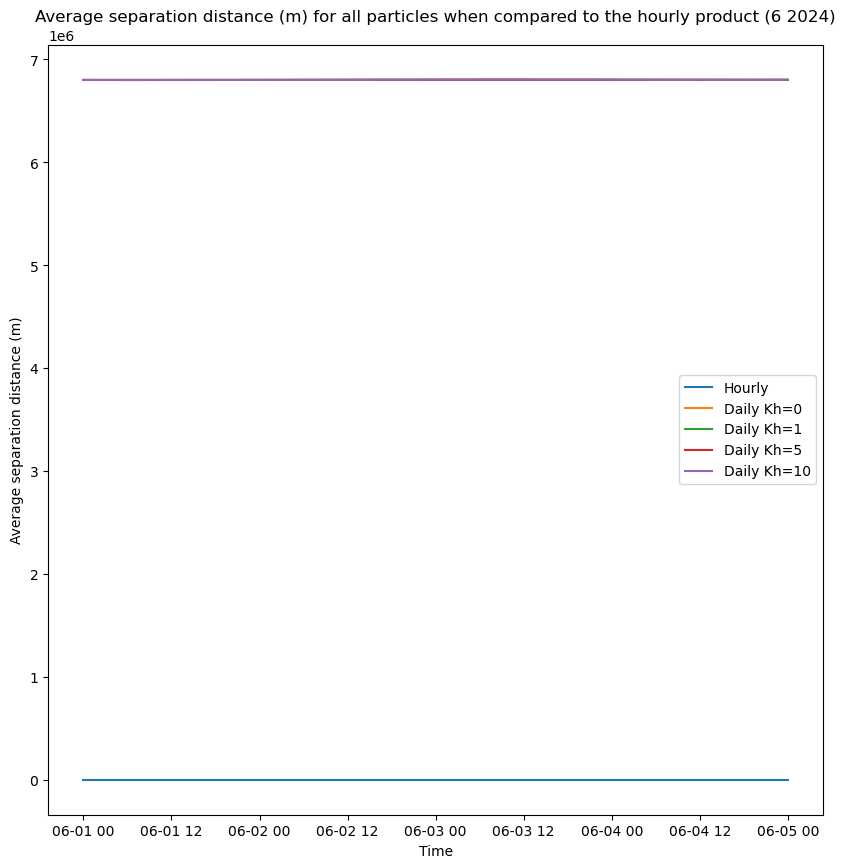

In [1]:
from datetime import datetime, timedelta
import datetime as dt
import numpy as np
import pandas as pd
import xarray as xr
import os
import matplotlib.pyplot as plt

def haversine(lon1, lon2, lat1, lat2, R = 6371000):
    dlon = lon2 -lon1
    dlat = lat2 -lat1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * np.arcsin(np.sqrt(a)) * R

month = 6 
#Average separation distance compared to a baseline (hourly product) assuming it is the most accurate
fig, ax = plt.subplots(figsize=(10, 10))

ds = xr.open_dataset('/scratch/project_2018610/opendrift_outputs/sensibility_test_diffusivity/sensibility_test_diffusivity_hourly_Kh_0_month_{}.nc'.format(month))
time, lon, lat = [ds[key] for key in ['time', 'lon', 'lat']]
lon = np.deg2rad(lon)
lat = np.deg2rad(lon)
d = haversine(lon, lon, lat, lat)    
ax.plot(time, d.mean(axis=0), label='Hourly')

for Kh in [0, 1, 5, 10]:
    
    ds = xr.open_dataset('/scratch/project_2018610/opendrift_outputs/sensibility_test_diffusivity/sensibility_test_diffusivity_daily_Kh_{}_month_{}.nc'.format(Kh, month))
    #Use of Haversine formula to calculate the distances
    #Caution ! Conversion in radian
    d = haversine(lon, np.deg2rad(ds.lon), lat, np.deg2rad(ds.lat))    
    ax.plot(time, d.mean(axis=0), label=f'Daily Kh={Kh}')

ax.legend()
ax.set_title(f'Average separation distance (m) for all particles when compared to the hourly product ({month} 2024)')
ax.set_xlabel("Time")
ax.set_ylabel("Average separation distance (m)")
plt.show()
fig.savefig('sensibility_test_diffusivity_{}'.format(month))



### Using the average pair separation distance ###

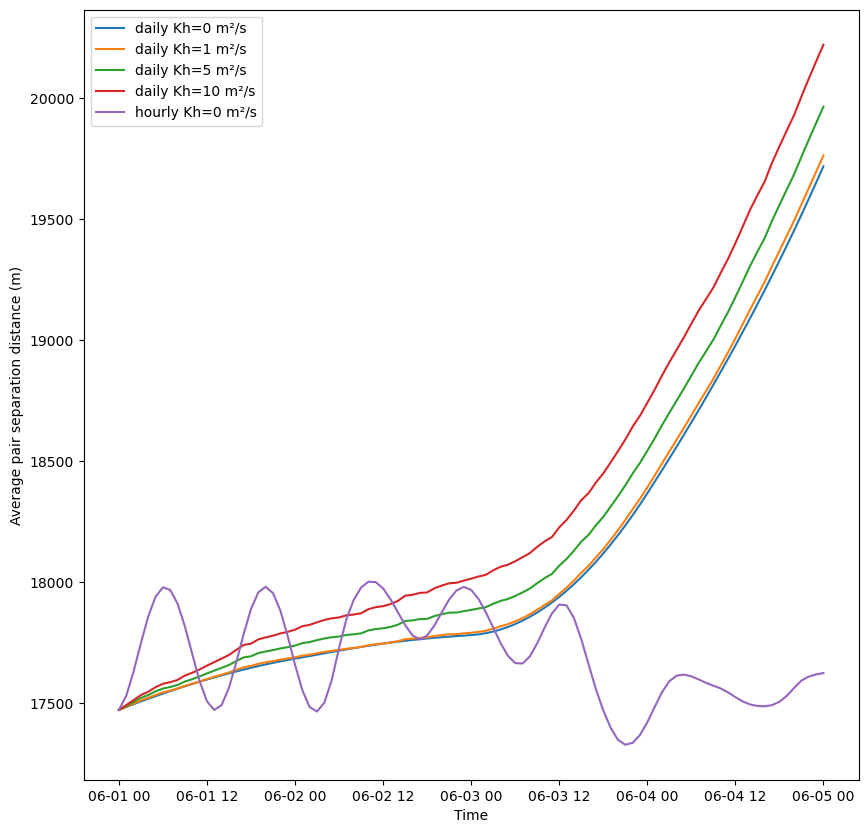

In [2]:
month = 6
fig, ax = plt.subplots(figsize=(10, 10))

for product in ['daily', 'hourly']:
    if product == 'daily' :
        list_Kh = [0, 1, 5, 10]
    else :
        list_Kh = [0]        
    for Kh in list_Kh :
        
        ds = xr.open_dataset('/scratch/project_2018610/opendrift_outputs/sensibility_test_diffusivity/sensibility_test_diffusivity_{}_Kh_{}_month_{}.nc'.format(product, Kh, month))
        lat = np.deg2rad(ds.lat.values)
        lon = np.deg2rad(ds.lon.values)
        npart, nt = lat.shape
        mean_dist = np.zeros(nt)

        for t in range(nt):
            lat_t = lat[:,t]
            lon_t = lon[:,t]
            
            # Create pairwise matrices
            lat1 = lat_t[:, None]
            lat2 = lat_t[None, :]
            lon1 = lon_t[:, None]
            lon2 = lon_t[None, :]
            
            d = haversine(lon1, lon2, lat1, lat2)
            
            # Take only upper triangle (unique pairs, exclude diagonal)
            i, j = np.triu_indices(npart, k=1)
            mean_dist[t] = d[i, j].mean()
 
    
        ax.plot(ds.time, mean_dist, label=f'{product} Kh={Kh} m²/s')

ax.legend()
# ax.set_title(f'Average pair separation distance (m)  ({month} 2024)')
ax.set_xlabel("Time")
ax.set_ylabel("Average pair separation distance (m)")
plt.show()
fig.savefig('figures_without_title/sensibility_test_diffusivity_pair_separation_distance_month_{}'.format(month))